# Credit Risk

## 1. Load Data

• Read accepted and rejected loan datasets from raw CSV files.

• Merge datasets into a single DataFrame for modeling.

• Ensure consistent feature names and data types.

### i) Read Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd

# Load CSV files, skipping bad lines
df_accepted = pd.read_csv("/content/sample_data/accepted.csv", on_bad_lines='skip')

/tmp/ipython-input-1536988319.py:4: DtypeWarning: Columns (0,3,4,6,7,13,19,25,27,28,29,30,31,32,33,34,35,36,38,39,40,41,42,43,44,45,46,48,52,53,54,55,57,59,60,61,62,63,64,67,68,71,72,73,75,78,79,82,83,84,85,87,88,90,91,97,98,99,100,101,102,105,106,107,108,112,113,114,115,116,117,118,121,122,123,124,125,127,133,137,140,141,142) have mixed types. Specify dtype option on import or set low_memory=False.
  df_accepted = pd.read_csv("/content/sample_data/accepted.csv", on_bad_lines='skip')


In [3]:
df_rejected = pd.read_csv("/content/sample_data/rejected.csv", on_bad_lines='skip')

/tmp/ipython-input-769542176.py:1: DtypeWarning: Columns (0,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rejected = pd.read_csv("/content/sample_data/rejected.csv", on_bad_lines='skip')


#### List of column names

In [4]:
df_accepted.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [5]:
df_rejected = df_rejected.rename(columns={
    "Amount Requested": "LoanAmount",
    "Application Date": "Date",
    "Loan Title": "purpose",
    "Risk_Score": "riskScore",
    "Debt-To-Income Ratio": "debtToIncomeRatio",
    "Zip Code": "zipCode",
    "State": "state",
    "Employment Length": "employmentLength",
    "Policy Code": "policyCode"
})


In [6]:
df_rejected = df_rejected.drop(columns=["riskScore"])

In [7]:
df_rejected.columns

Index(['LoanAmount', 'Date', 'purpose', 'debtToIncomeRatio', 'zipCode',
       'state', 'employmentLength', 'policyCode'],
      dtype='object')

#### Common Columns

In [8]:
df_accepted = df_accepted.rename(columns={
    "loan_amnt": "LoanAmount",
    "issue_d": "Date",
    "purpose": "purpose",
    "dti": "debtToIncomeRatio",
    "zip_code": "zipCode",
    "addr_state": "state",
    "emp_length": "employmentLength",
    "policy_code": "policyCode"
})

In [9]:
#only keep common columns

rej_cols = [
    "LoanAmount",
    "Date",
    "purpose",
    "debtToIncomeRatio",
    "zipCode",
    "state",
    "employmentLength",
    "policyCode"
]

df_accepted = df_accepted[rej_cols]


In [10]:
# accepted = 0
df_accepted["target"] = 0

# rejected = 1
df_rejected["target"] = 1


In [11]:
df_accepted.head()

,LoanAmount,Date,purpose,debtToIncomeRatio,zipCode,state,employmentLength,policyCode,target
0,3600.0,Dec-2015,debt_consolidation,5.91,190xx,PA,10+ years,1.0,0
1,24700.0,Dec-2015,small_business,16.06,577xx,SD,10+ years,1.0,0
2,20000.0,Dec-2015,home_improvement,10.78,605xx,IL,10+ years,1.0,0
3,35000.0,Dec-2015,debt_consolidation,17.06,076xx,NJ,10+ years,1.0,0
4,10400.0,Dec-2015,major_purchase,25.37,174xx,PA,3 years,1.0,0


In [12]:
df_rejected.head()

,LoanAmount,Date,purpose,debtToIncomeRatio,zipCode,state,employmentLength,policyCode,target
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,10%,481xx,NM,4 years,0.0,1
1,1000.0,2007-05-26,Consolidating Debt,10%,010xx,MA,< 1 year,0.0,1
2,11000.0,2007-05-27,Want to consolidate my debt,10%,212xx,MD,1 year,0.0,1
3,6000.0,2007-05-27,waksman,38.64%,017xx,MA,< 1 year,0.0,1
4,1500.0,2007-05-27,mdrigo,9.43%,209xx,MD,< 1 year,0.0,1


### ii) Merge Both datasets

In [13]:

df_merged = pd.concat(
    [df_accepted, df_rejected],
    ignore_index=True
)


In [14]:
df=df_merged

# 2. Data Cleaning

• Handle missing values (drop or impute based on context).

• Drop irrelevant columns (e.g., unique IDs, URLs).

• Loan purpose categorization:

  Original dataset had 30k+ loan purposes.

        o Applied TF-IDF clustering locally to group similar purposes.
        
        o Selected top 10 examples per cluster and used OpenAI API to assign meaningful labels.
        
        o Reduced 30k+ categories to 50 relevant categories.

In [15]:
df["LoanAmount"] = pd.to_numeric(df["LoanAmount"], errors="coerce")

In [16]:
df["purpose"] = df["purpose"].str.replace("_", " ").str.strip()

In [17]:
df["debtToIncomeRatio"] = (
    df["debtToIncomeRatio"]
    .astype(str)                 # ensure string
    .str.replace("%", "", regex=False)
    .str.strip()
)

In [18]:
df["debtToIncomeRatio"] = pd.to_numeric(df["debtToIncomeRatio"], errors="coerce")

In [19]:
df["zipCode"] = df["zipCode"].astype(str).str.strip()

In [20]:
df["state"] = df["state"].str.upper().str.strip()


In [21]:
def clean_emp_length(val):
    if pd.isna(val) or str(val).lower() in ["n/a", "na"]:
        return 0
    val = str(val).replace(" years", "").replace(" year", "").replace("< 1", "0").replace("+", "")
    try:
        return int(val)
    except:
        return 0

In [22]:
df["employmentLength"] = df["employmentLength"].apply(clean_emp_length)

In [23]:
print(df.head())

   LoanAmount      Date             purpose  debtToIncomeRatio zipCode state  \
0      3600.0  Dec-2015  debt consolidation               5.91   190xx    PA   
1     24700.0  Dec-2015      small business              16.06   577xx    SD   
2     20000.0  Dec-2015    home improvement              10.78   605xx    IL   
3     35000.0  Dec-2015  debt consolidation              17.06   076xx    NJ   
4     10400.0  Dec-2015      major purchase              25.37   174xx    PA   

   employmentLength policyCode  target  
0                10        1.0       0  
1                10        1.0       0  
2                10        1.0       0  
3                10        1.0       0  
4                 3        1.0       0  


In [24]:
print(df.dtypes)

LoanAmount           float64
Date                  object
purpose               object
debtToIncomeRatio    float64
zipCode               object
state                 object
employmentLength       int64
policyCode            object
target                 int64
dtype: object


In [25]:
# Drop Date and policyCode columns
df = df.drop(columns=["Date", "policyCode"], errors="ignore")


In [26]:
# missing values per column
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

LoanAmount            8
purpose              61
debtToIncomeRatio    41
state                51
dtype: int64


In [27]:
df.head()

,LoanAmount,purpose,debtToIncomeRatio,zipCode,state,employmentLength,target
0,3600.0,debt consolidation,5.91,190xx,PA,10,0
1,24700.0,small business,16.06,577xx,SD,10,0
2,20000.0,home improvement,10.78,605xx,IL,10,0
3,35000.0,debt consolidation,17.06,076xx,NJ,10,0
4,10400.0,major purchase,25.37,174xx,PA,3,0


### i) Handle Missing values

In [28]:
# Separate target
y = df["target"].copy()    # keep target

#  Keep only features
X = df.drop(columns=["target"])

# Drop rows with any NaN in features
X = X.dropna().reset_index(drop=True)

#  Align target with cleaned features
y = y[X.index].reset_index(drop=True)

#  Sanity check
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Missing values in features:\n", X.isnull().sum())
print("Missing values in target:\n", y.isnull().sum())


Features shape: (1515876, 6)
Target shape: (1515876,)
Missing values in features:
 LoanAmount           0
purpose              0
debtToIncomeRatio    0
zipCode              0
state                0
employmentLength     0
dtype: int64
Missing values in target:
 0


## ii) Loan Purpose Column Categorization

In [29]:
num_categories = X["purpose"].nunique()
print(num_categories)


58542


there are 72k+ loan purpouse types. Imagine if I consolidated them into generic categories, like : "Home loan", "wedding", "education" etc. I'd be able to gather far better insights.

For this I am using TFIDF and Open AI API to generate a generic category name. I want to consolidate 72k+ types into 30 broader categories.

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
import pandas as pd

# Prepare the corpus
corpus = X["purpose"].astype(str).values  # ensure string


In [31]:
# 2 Compute TF-IDF vectors
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)  # limit features to 5k for speed
X_tfidf = tfidf.fit_transform(corpus)

In [32]:
# 3️Cluster into 30 categories using KMeans
n_clusters = 30
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_tfidf)

In [33]:
pip install groq

In [34]:
#  Add cluster labels to dataframe
X["PurposeCategory"] = ["c" + str(i) for i in clusters]

In [35]:
# 5️Build a hashmap: cluster -> list of example purposes
purpose_map = {}
for i in range(n_clusters):
    # take 20 example purpose names from each cluster
    examples = X.loc[X["PurposeCategory"] == f"c{i}", "purpose"].unique()[:20].tolist()
    purpose_map[f"c{i}"] = examples

In [36]:

# 6 Sanity check
print("Purpose categories assigned:", X["PurposeCategory"].nunique())
print("Example mapping for c0:", purpose_map["c0"])

Purpose categories assigned: 30
Example mapping for c0: ['debt consolidation', 'debt consonsolidation', 'Debt Consolidation', 'Debt consolidation', 'Consolidation', 'consolidation', 'Manual Consolidation', 'Debt', 'Card debt consolidation', 'Another Go At Debt Consolidation', 'Get Out of Debt', 'For Consolidation', 'Consolidation of Credit debt', 'out of debt', 'Bill Consolidation', 'consoildating debt', 'GET OUT OF DEBT', 'Consolidation Debt', 'debt consolidation/other', 'Abolish My Debt']


for key,val in purpose_map.items():
    print(key, val)

How this works

TF-IDF: Converts each purpose string into a numeric vector representing important words.

KMeans clustering: Groups the 72k+ unique purpose strings into 30 clusters based on semantic similarity.

New column: PurposeCategory contains c0, c1, ..., c29.

Hashmap: purpose_map stores a few example names per cluster for reference.

In [37]:
!pip install groq

In [38]:
import os
os.environ["GROQ_API_KEY"] = "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"

In [39]:
import os
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

def assign_category_name(cluster_id, examples):
    """Send 10 examples to Groq and get a generic category name."""
    sample = examples[:10]
    prompt = f"""You are a financial data analyst. I have a cluster of loan purpose descriptions that have been grouped together.

Cluster ID: {cluster_id}
Sample entries from this cluster:
{chr(10).join(f'- {e}' for e in sample)}

Based on these loan purpose descriptions, assign ONE short, unique, generic category name (2-4 words max) that best represents this cluster.
Respond with ONLY the category name, nothing else. No explanation, no punctuation, just the category name."""

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=20
    )
    return response.choices[0].message.content.strip()


# Build genericPurpose hashmap
genericPurpose = {}

for cluster_id, examples in purpose_map.items():
    print(f"Processing {cluster_id} ({len(examples)} entries)...")
    name = assign_category_name(cluster_id, examples)
    genericPurpose[cluster_id] = name
    print(f"  → {cluster_id}: '{name}'")

print("\nFinal genericPurpose map:")
print(genericPurpose)

Processing c0 (20 entries)...
  → c0: 'Debt Consolidation Financing'
Processing c1 (20 entries)...
  → c1: 'Credit Card Consolidation'
Processing c2 (20 entries)...
  → c2: 'Major Home Purchase'
Processing c3 (20 entries)...
  → c3: 'Home Improvement Loan'
Processing c4 (20 entries)...
  → c4: 'Home Improvement Loan'
Processing c5 (20 entries)...
  → c5: 'Car Loan Purpose'
Processing c6 (20 entries)...
  → c6: 'Small Business Financing'
Processing c7 (20 entries)...
  → c7: 'Moving Expenses'
Processing c8 (20 entries)...
  → c8: 'Medical Debt Consolidation'
Processing c9 (20 entries)...
  → c9: 'Personal Vacation Financing'
Processing c10 (20 entries)...
  → c10: 'Wedding Expenses'
Processing c11 (20 entries)...
  → c11: 'Home Purchase Financing'
Processing c12 (20 entries)...
  → c12: 'Education Expenses'
Processing c13 (20 entries)...
  → c13: 'Personal Loan Financing'
Processing c14 (20 entries)...
  → c14: 'Small Business Financing'
Processing c15 (20 entries)...
  → c15: 'Auto Loa

In [40]:
X["GenericPurpose"] = X["PurposeCategory"].apply(
    lambda x: genericPurpose.get(x)
)

In [41]:
# 4️Sanity check
print(X[["purpose","PurposeCategory","GenericPurpose"]].head())

              purpose PurposeCategory                GenericPurpose
0  debt consolidation              c0  Debt Consolidation Financing
1      small business              c6      Small Business Financing
2    home improvement              c4         Home Improvement Loan
3  debt consolidation              c0  Debt Consolidation Financing
4      major purchase              c2           Major Home Purchase


How it works

Loops through your cluster keys (c0, c1…).

Sends a list of 20 example purposes to OpenAI.

API returns a concise generic category name.

Creates a new column GenericPurpose in the main dataframe.

* Cost Effectiveness : OpenAI API calls are expensive. So doing TFIDF locally and clustering them into 30 subsets helps reduce the loan. To get better quality clusters, increase k values.Litterally uses a few cents vs processing 72k+ lines of text would cost so much more.

## iii) Drop Irralevent columns

In [42]:
X = X.drop(columns=["purpose", "PurposeCategory","zipCode"], errors="ignore")

# sanity check
print(X.columns)


Index(['LoanAmount', 'debtToIncomeRatio', 'state', 'employmentLength',
       'GenericPurpose'],
      dtype='object')


# 3. Data Exploration

In [43]:
# Convert GenericPurpose (and any other categorical columns) to numeric codes
X_encoded = X.copy()

for col in X_encoded.select_dtypes(include="object").columns:
    X_encoded[col] = X_encoded[col].astype("category").cat.codes


# Data Preprocessing

Feature Encoding & Normalization

• Encode categorical features using one-hot encoding: Puppouse

• Normalize numerical features using MinMaxScaler or StandardScaler:
o Loan amount
o Debt-to-income ratio (DTI)


In [44]:
# Columns to one-hot encode
categorical_cols = ["GenericPurpose", "state"]

# One-hot encode
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# Check the new shape and some columns
print("New shape:", X_encoded.shape)
print(X_encoded.columns[:20])


New shape: (1515876, 92)
Index(['LoanAmount', 'debtToIncomeRatio', 'employmentLength',
       'GenericPurpose_Auto Loan Financing',
       'GenericPurpose_Business Financing',
       'GenericPurpose_Car Loan Financing', 'GenericPurpose_Car Loan Purpose',
       'GenericPurpose_Credit Card Consolidation',
       'GenericPurpose_Debt Consolidation',
       'GenericPurpose_Debt Consolidation Financing',
       'GenericPurpose_Debt Consolidation Loan',
       'GenericPurpose_Debt Refinancing', 'GenericPurpose_Education Expenses',
       'GenericPurpose_Education Financing',
       'GenericPurpose_Educational Financing',
       'GenericPurpose_High Interest Debt Payoff',
       'GenericPurpose_Home Improvement Loan',
       'GenericPurpose_Home Purchase Financing',
       'GenericPurpose_Major Home Purchase',
       'GenericPurpose_Medical Debt Consolidation'],
      dtype='object')


In [45]:
# Columns to one-hot encode
categorical_cols = ["GenericPurpose", "state"]

# One-hot encode
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# Force all one-hot columns to 0/1
for col in X_encoded.columns:
    if X_encoded[col].dtype == bool:
        X_encoded[col] = X_encoded[col].astype(int)

# Check the new shape and some columns
print("New shape:", X_encoded.shape)
print(X_encoded.columns[:20])

New shape: (1515876, 92)
Index(['LoanAmount', 'debtToIncomeRatio', 'employmentLength',
       'GenericPurpose_Auto Loan Financing',
       'GenericPurpose_Business Financing',
       'GenericPurpose_Car Loan Financing', 'GenericPurpose_Car Loan Purpose',
       'GenericPurpose_Credit Card Consolidation',
       'GenericPurpose_Debt Consolidation',
       'GenericPurpose_Debt Consolidation Financing',
       'GenericPurpose_Debt Consolidation Loan',
       'GenericPurpose_Debt Refinancing', 'GenericPurpose_Education Expenses',
       'GenericPurpose_Education Financing',
       'GenericPurpose_Educational Financing',
       'GenericPurpose_High Interest Debt Payoff',
       'GenericPurpose_Home Improvement Loan',
       'GenericPurpose_Home Purchase Financing',
       'GenericPurpose_Major Home Purchase',
       'GenericPurpose_Medical Debt Consolidation'],
      dtype='object')


Only creates 21 dummy columns

Captures high-impact neighborhoods (like UES vs Brooklyn)

In [46]:
from sklearn.preprocessing import StandardScaler

# Numeric columns to normalize
numeric_cols = ['LoanAmount', 'debtToIncomeRatio', 'employmentLength']

# Copy X_encoded to avoid modifying in place
X_normalized = X_encoded.copy()

# Initialize scaler
scaler = StandardScaler()

# Fit & transform only numeric columns
X_normalized[numeric_cols] = scaler.fit_transform(X_normalized[numeric_cols])

# Quick check
X_normalized.head()


,LoanAmount,debtToIncomeRatio,employmentLength,GenericPurpose_Auto Loan Financing,GenericPurpose_Business Financing,GenericPurpose_Car Loan Financing,GenericPurpose_Car Loan Purpose,GenericPurpose_Credit Card Consolidation,GenericPurpose_Debt Consolidation,GenericPurpose_Debt Consolidation Financing,...,state_TN,state_TX,state_TXEARS,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,-0.684109,-0.011652,2.782877,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0.809517,-0.011412,2.782877,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.476813,-0.011536,2.782877,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.538632,-0.011388,2.782877,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,-0.202751,-0.011192,0.454338,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 4. Feature Engineering

Create flags and interaction features:

o high_dti_flag = 1 if dti > 30 else 0

o long_term_employment = 1 if emp_length >= 10 else 0

o loan_dti_interaction = loan_amount * dti

In [47]:
# Copy to avoid modifying previous DF
X_final = X_normalized.copy()

# High DTI flag
X_final['high_dti_flag'] = (X_final['debtToIncomeRatio'] > 30).astype(int)

# Long-term employment flag
X_final['long_term_employment'] = (X_final['employmentLength'] >= 10).astype(int)

# Loan x DTI interaction
X_final['loan_dti_interaction'] = X_final['LoanAmount'] * X_final['debtToIncomeRatio']

# Quick check
X_final.head()


,LoanAmount,debtToIncomeRatio,employmentLength,GenericPurpose_Auto Loan Financing,GenericPurpose_Business Financing,GenericPurpose_Car Loan Financing,GenericPurpose_Car Loan Purpose,GenericPurpose_Credit Card Consolidation,GenericPurpose_Debt Consolidation,GenericPurpose_Debt Consolidation Financing,...,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,high_dti_flag,long_term_employment,loan_dti_interaction
0,-0.684109,-0.011652,2.782877,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0.007971
1,0.809517,-0.011412,2.782877,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-0.009238
2,0.476813,-0.011536,2.782877,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-0.005501
3,1.538632,-0.011388,2.782877,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,-0.017522
4,-0.202751,-0.011192,0.454338,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.002269


## Modeling (Risk & Profit Tradeoff)

In [48]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2, # 20% for testing
    random_state=42, # for reproducibility
    stratify=y # Stratify to maintain class balance in splits
)

In [49]:
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score, fbeta_score, roc_auc_score,
    classification_report, RocCurveDisplay)
import matplotlib.pyplot as plt


In [50]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f2_score = fbeta_score(y_test, y_pred, beta=2) # F2-score gives more weight to recall
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F2 Score: {f2_score:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Recall": recall,
        "F2 Score": f2_score,
        "ROC AUC": roc_auc
    }



In [51]:
# Logistic Regression Model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [52]:
# Random Forest Model
rf_soft = RandomForestClassifier(n_estimators=100, random_state=42)
rf_soft.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [53]:
# Gradient Boosting Model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [60]:
# Neural Network Model
nn_model = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=300, random_state=42, solver='adam')
nn_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=300, random_state=42)

In [61]:
# Update the evaluation code to include all four models
results = []

In [62]:
results.append(evaluate_model(lr_model, X_test, y_test, "Logistic Regression"))


--- Logistic Regression Results ---
Accuracy: 0.9219
Recall: 0.9855
F2 Score: 0.9741
ROC AUC: 0.8798
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.37      0.50     31548
           1       0.93      0.99      0.96    271628

    accuracy                           0.92    303176
   macro avg       0.84      0.68      0.73    303176
weighted avg       0.91      0.92      0.91    303176



In [63]:
results.append(evaluate_model(rf_soft, X_test, y_test, "Random Forest"))


--- Random Forest Results ---
Accuracy: 0.9321
Recall: 0.9684
F2 Score: 0.9660
ROC AUC: 0.9265
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.62      0.66     31548
           1       0.96      0.97      0.96    271628

    accuracy                           0.93    303176
   macro avg       0.83      0.79      0.81    303176
weighted avg       0.93      0.93      0.93    303176



In [64]:
results.append(evaluate_model(gb_model, X_test, y_test, "Gradient Boosting"))


--- Gradient Boosting Results ---
Accuracy: 0.9417
Recall: 0.9790
F2 Score: 0.9745
ROC AUC: 0.9437
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.62      0.69     31548
           1       0.96      0.98      0.97    271628

    accuracy                           0.94    303176
   macro avg       0.87      0.80      0.83    303176
weighted avg       0.94      0.94      0.94    303176



In [65]:
results.append(evaluate_model(nn_model, X_test, y_test, "Neural Network"))


--- Neural Network Results ---
Accuracy: 0.9371
Recall: 0.9700
F2 Score: 0.9680
ROC AUC: 0.9258
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.65      0.68     31548
           1       0.96      0.97      0.97    271628

    accuracy                           0.94    303176
   macro avg       0.84      0.81      0.82    303176
weighted avg       0.93      0.94      0.94    303176



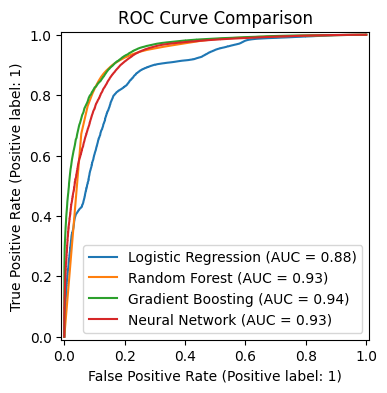

In [66]:
# Plot ROC Curves for all models
plt.figure(figsize=(4, 4))
ax = plt.gca()
RocCurveDisplay.from_estimator(lr_model, X_test, y_test, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_estimator(rf_soft, X_test, y_test, name="Random Forest", ax=ax)
RocCurveDisplay.from_estimator(gb_model, X_test, y_test, name="Gradient Boosting", ax=ax)
RocCurveDisplay.from_estimator(nn_model, X_test, y_test, name="Neural Network", ax=ax)
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

In [67]:
# Summarize the results in a DataFrame

results_df = pd.DataFrame(results)
print("Summary of Results:")
print(results_df)

Summary of Results:
                 Model  Accuracy    Recall  F2 Score   ROC AUC
0  Logistic Regression  0.921880  0.985469  0.974144  0.879813
1        Random Forest  0.932129  0.968405  0.965978  0.926542
2    Gradient Boosting  0.941664  0.978990  0.974489  0.943696
3       Neural Network  0.937060  0.970003  0.968017  0.925829
